In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
import seaborn as sns

vs = pd.read_csv("variablestar_subset.csv")

vs['Class'].unique()
vs.head()

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,i_scienceFluxMean,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i
0,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,...,45757.542969,20.093173,19.838917,19.748843,0.254256,0.090074,0.344330,0.000000,2661.922705,9777.694531
1,579575256428052807,6.028941,-72.575914,4831.474609,-25320.785156,-179.425217,NaN,30822.791670,12747.179363,1.633590e-12,...,83378.773438,18.961470,19.236027,19.097361,-0.274557,0.138666,-0.135891,0.000000,39231.008838,25505.434082
2,579575256428052608,6.131206,-72.535870,3551.469238,2256.967773,-683.594910,NaN,20084.917872,15072.810519,0.000000e+00,...,60267.218750,19.681180,19.270087,19.449797,0.411093,-0.179710,0.231382,0.000000,52197.120898,27210.721436
3,579575256428052935,5.749370,-72.562515,-2458.857910,-3932.516113,-4707.509277,33713.217524,15083.356053,19146.177524,9.085750e+03,...,54046.925781,19.434004,19.560524,19.568073,-0.126520,-0.007549,-0.134068,42909.920703,36705.485596,33807.777527
4,579575874903343585,6.531026,-72.410982,1884.615479,-1872.704224,-1940.932861,17228.444619,10182.526231,7189.145685,1.940270e+04,...,55119.921875,19.595041,19.463617,19.546729,0.131424,-0.083112,0.048312,33650.281738,27545.775830,16909.457520


In [127]:
vs.isna().sum()

diaObjectId                0
ra                         0
dec                        0
g_psfFluxMean            416
r_psfFluxMean             14
i_psfFluxMean            110
g_psfFluxSigma           458
r_psfFluxSigma            23
i_psfFluxSigma           172
g_psfFluxChi2            416
r_psfFluxChi2             14
i_psfFluxChi2            110
g_psfFluxStetsonJ        458
r_psfFluxStetsonJ         23
i_psfFluxStetsonJ        172
g_psfFluxMAD             416
r_psfFluxMAD              14
i_psfFluxMAD             110
g_psfFluxNdata           416
r_psfFluxNdata            14
i_psfFluxNdata           110
nDiaSources                0
Region                     0
Class                      0
otype                     95
otype_flag                 0
g_psfFluxPercentile95    416
r_psfFluxPercentile95     14
i_psfFluxPercentile95    110
g_psfFluxPercentile50    416
r_psfFluxPercentile50     14
i_psfFluxPercentile50    110
g_psfFluxPercentile05    416
r_psfFluxPercentile05     14
i_psfFluxPerce

In [128]:
vs_RR = vs[vs['Class'] == 'RRLyrae']
# vs_C = vs[vs['Class'] == 'Cepheid']
vs_M = vs[vs['Class'] == 'LPV']

vs_RR.to_csv("vs_RR.csv", index=False)
# vs_C.to_csv("vs_Cepheid.csv", index=False)
vs_M.to_csv("vs_LPV.csv", index=False)

# Skipping Cepheids for this since we don't have a large enough dataset of known Cepheids in our regions

In [129]:
vs_RR = vs[vs['Class'] == 'RRLyrae'].dropna(subset=key_cols)
# vs_C  = vs[vs['Class'] == 'Cepheid'].dropna(subset=key_cols)
vs_M  = vs[vs['Class'] == 'LPV'].dropna(subset=key_cols)

vs_RR.reset_index(drop=True, inplace=True)
vs_C.reset_index(drop=True, inplace=True)
vs_M.reset_index(drop=True, inplace=True)

In [130]:
for name, subset in zip(["RRLyrae", "LPV"], [vs_RR, vs_M]): # "Cepheid", "vs_C"
    print(f"\n{name} Summary:")
    for band in ['g', 'r', 'i']:
        chi2_col = f"{band}_psfFluxChi2"
        sigma_col = f"{band}_psfFluxSigma"
        print(f"{band}-band χ² mean = {subset[chi2_col].mean():.2f}, σ = {subset[chi2_col].std():.2f}")
        print(f"{band}-band σ (psfFlux) mean = {subset[sigma_col].mean():.2f}")


RRLyrae Summary:
g-band χ² mean = 113928.25, σ = 400331.64
g-band σ (psfFlux) mean = 22209.59
r-band χ² mean = 149667.57, σ = 583107.32
r-band σ (psfFlux) mean = 20531.21
i-band χ² mean = 19406.36, σ = 56522.23
i-band σ (psfFlux) mean = 16724.84

LPV Summary:
g-band χ² mean = 389.35, σ = 1005.82
g-band σ (psfFlux) mean = 4582.69
r-band χ² mean = 11300.52, σ = 14590.17
r-band σ (psfFlux) mean = 17721.07
i-band χ² mean = 196871.50, σ = 490194.93
i-band σ (psfFlux) mean = 109179.36


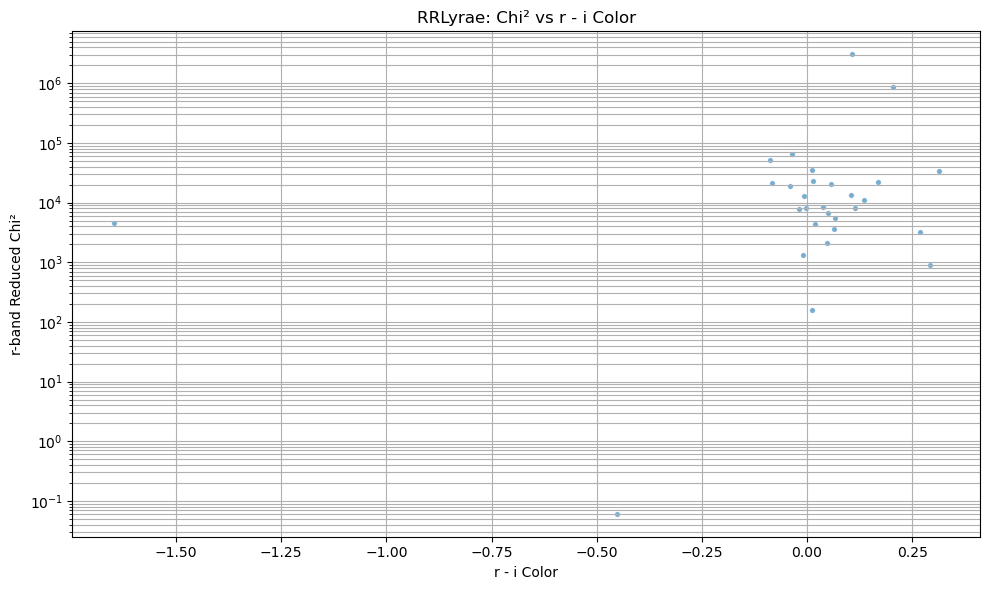

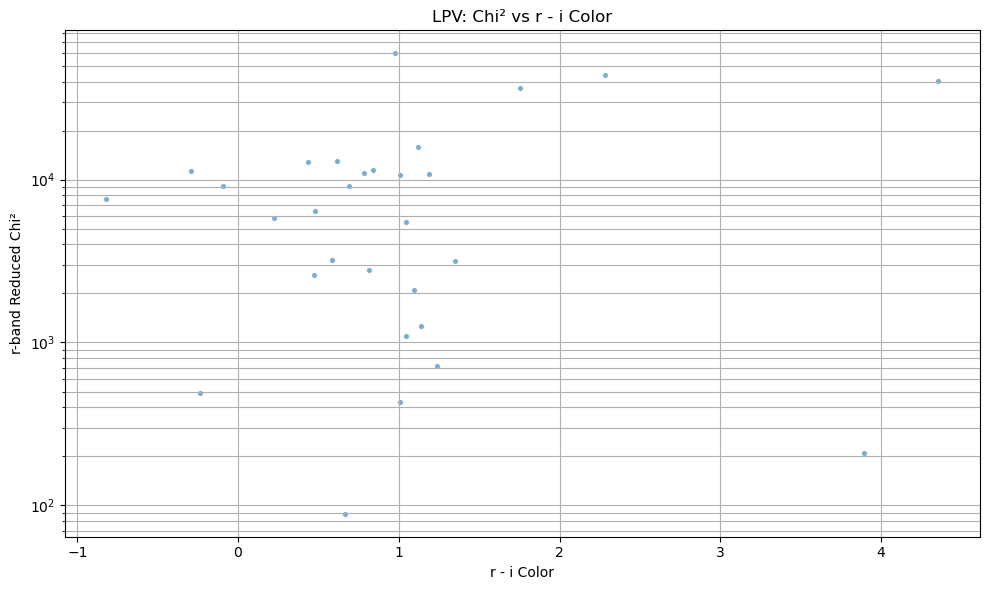

In [131]:
for name, subset in zip(["RRLyrae", "LPV"], [vs_RR, vs_M]):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=subset, x="r_i", y="r_psfFluxChi2", alpha=0.6, s=15)
    plt.yscale("log")
    plt.xlabel("r - i Color")
    plt.ylabel("r-band Reduced Chi²")
    plt.title(f"{name}: Chi² vs r - i Color")
    plt.grid(True, which='both')
    plt.tight_layout()
    plt.show()

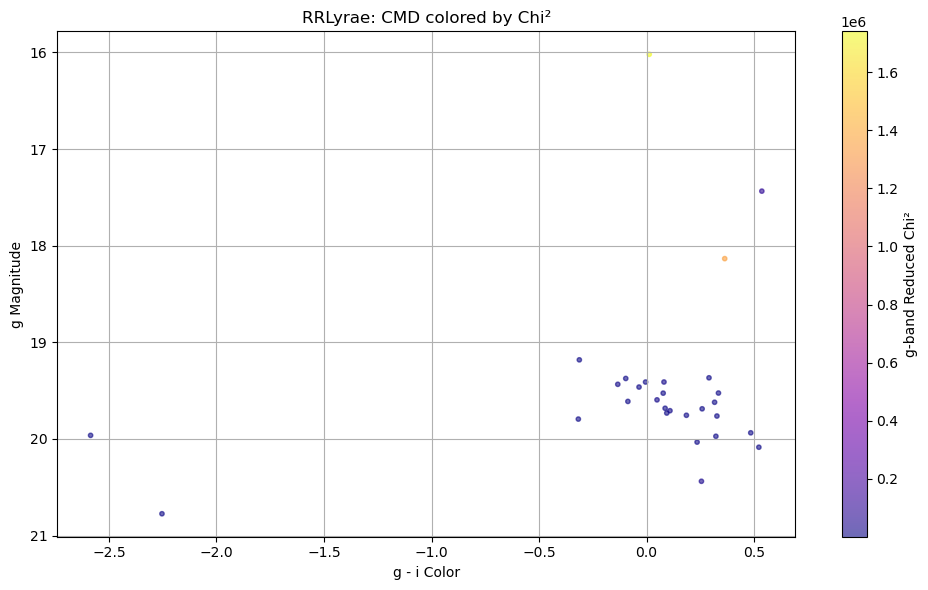

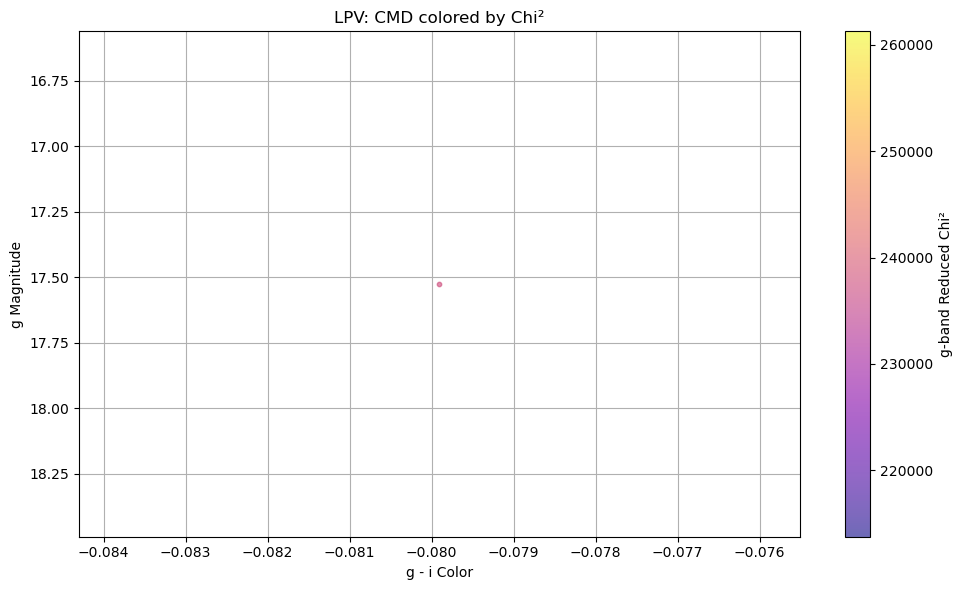

In [132]:
for name, subset in zip(["RRLyrae", "LPV"], [vs_RR, vs_C, vs_M]):
    plt.figure(figsize=(10, 6))
    sc = plt.scatter(subset["g_i"], subset["gmag"], c=subset["g_psfFluxChi2"], cmap='plasma', s=10, alpha=0.6)
    plt.colorbar(sc, label="g-band Reduced Chi²")
    plt.xlabel("g - i Color")
    plt.ylabel("g Magnitude")
    plt.title(f"{name}: CMD colored by Chi²")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [133]:
for name, subset in zip(["RRLyrae", "LPV"], [vs_RR, vs_M]):
    chi2 = subset["g_psfFluxChi2"]
    chi2_clean = chi2[chi2 < 1e4]
    mu = chi2_clean.mean()
    sigma = chi2_clean.std()
    print(f"{name} (g-band): μ = {mu:.2f}, σ = {sigma:.2f}")
    print(f"   2σ = {mu + 2*sigma:.2f}, 3σ = {mu + 3*sigma:.2f}")

RRLyrae (g-band): μ = 1907.66, σ = 2282.12
   2σ = 6471.90, 3σ = 8754.02
LPV (g-band): μ = 389.35, σ = 1005.82
   2σ = 2401.00, 3σ = 3406.82


Number of outliers: 79
1       5837.170000
2      23896.600000
3      12708.900000
4      21548.700000
7       5561.620000
           ...     
425    41906.101562
434    10413.700195
448     5520.990234
453    11486.599609
454    28723.800781
Name: r_psfFluxChi2, Length: 79, dtype: float64


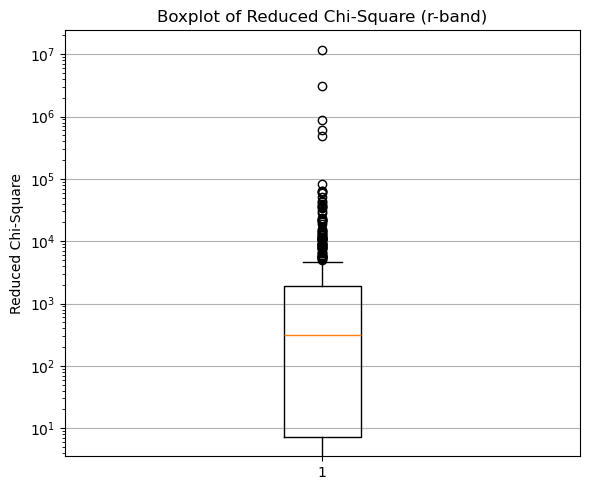

In [134]:
r_band_chi2 = vs['r_psfFluxChi2'].dropna()

q1 = np.percentile(r_band_chi2, 25)
q3 = np.percentile(r_band_chi2, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = r_band_chi2[(r_band_chi2 < lower_bound) | (r_band_chi2 > upper_bound)]

print("Number of outliers:", len(outliers))
print(outliers)
outliers.to_csv("r_band_chi2_outliers.csv", index=True)

# Plot boxplot
plt.figure(figsize=(6, 5))
plt.boxplot(r_band_chi2)
plt.yscale("log")
plt.ylabel("Reduced Chi-Square")
plt.title("Boxplot of Reduced Chi-Square (r-band)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

What we know now and what we need to know 

**1) Feature Distributions**

1. Chi-Square (χ²) values across bands show clear scale differences by class:
2. Cepheids have the highest χ² means (especially in r-band), although it's very uncertain to see what the rest of Cepheid data looks like.
3. RRLyrae have high χ² as well, but generally lower than Cepheids.
4. LPVs have relatively low g- and r-band χ², but a very high i-band χ².

**2) Flux Uncertainty Patterns (σ of PSF Flux)**

1. LPVs show very high i-band flux uncertainty — possibly due to their red colors and long variability.
2. Cepheids show high uncertainties across all bands.
3. RRLyrae are more moderate in flux uncertainties.

**3) Color–Magnitude and χ²–Color Structure**

1. CMDs colored by χ² (useful for clustering by variability and color).
2. χ² vs color scatter (useful for defining decision boundaries or thresholding).

In [135]:
# z-score standardization
r_mean = vs['r_psfFluxChi2'].mean()
r_std = vs['r_psfFluxChi2'].std()
vs['z_r_chi2'] = (vs['r_psfFluxChi2'] - r_mean) / r_std

r_sig_mean = vs['r_psfFluxSigma'].mean()
r_sig_std = vs['r_psfFluxSigma'].std()
vs['z_r_fluxsig'] = (vs['r_psfFluxSigma'] - r_sig_mean) / r_sig_std

# min-max normalization
r_min = vs['r_psfFluxChi2'].min()
r_max = vs['r_psfFluxChi2'].max()
vs['minmax_r_chi2'] = (vs['r_psfFluxChi2'] - r_min) / (r_max - r_min)

# composite features
vs['r_chi2_over_sigma'] = vs['r_psfFluxChi2'] / vs['r_psfFluxSigma'] # chi-square to uncertainty ratio
# log-transformed chi2 due to skew, this stabilizes it
vs['log_r_chi2'] = np.log10(vs['r_psfFluxChi2'] + 1)
# z-scored chi2
vs['z_r_chi2'] = (vs['r_psfFluxChi2'] - r_mean) / r_std

# since we don't have any other reliable bands 
vs['r_minus_i'] = vs['rmag'] - vs['imag']

Classification Report:

              precision    recall  f1-score   support

     Cepheid       0.00      0.00      0.00         4
         LPV       1.00      0.97      0.99        36
     RRLyrae       0.93      1.00      0.96        67

    accuracy                           0.95       107
   macro avg       0.64      0.66      0.65       107
weighted avg       0.92      0.95      0.94       107



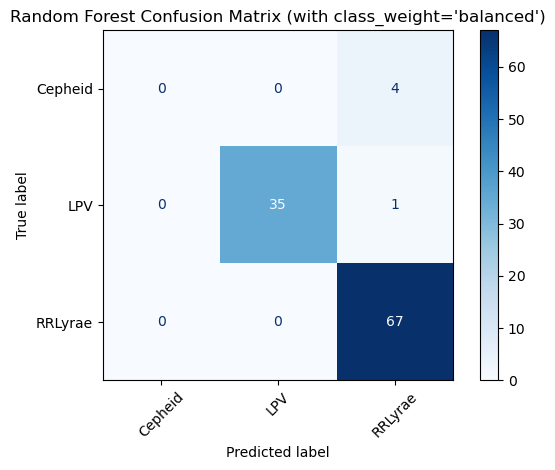


Feature Importances:
r_psfFluxChi2: 0.027
r_psfFluxSigma: 0.054
log_r_chi2: 0.029
r_chi2_over_sigma: 0.035
z_r_chi2: 0.030
r_minus_i: 0.199
r_psfFluxMAD: 0.127
r_psfFluxLinearSlope: 0.027
r_psfFluxMaxSlope: 0.159
rmag: 0.228
amp_r: 0.085


In [136]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

features = [
    'r_psfFluxChi2',
    'r_psfFluxSigma',
    'log_r_chi2',
    'r_chi2_over_sigma',
    'z_r_chi2',
    'r_minus_i',
    'r_psfFluxMAD',
    'r_psfFluxLinearSlope',
    'r_psfFluxMaxSlope',
    'rmag',
    'amp_r',
]
# Not Important: r_psfFluxMean, r_psfFluxStetsonJ, r_psfFluxSkew

X = vs[features].dropna()
y = vs.loc[X.index, 'Class']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# Create and train Random Forest with class weighting because there's like 4 cepheids and that fucking sucks
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    # class_weight='balanced'
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

disp = ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    cmap='Blues',
    xticks_rotation=45
)
plt.title("Random Forest Confusion Matrix (with class_weight='balanced')")
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
importances = clf.feature_importances_
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.3f}")

from sklearn.metrics import accuracy_score

In [137]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 95.33%
